In [1]:
import csv
import sys

import matplotlib.pyplot as plt
import numpy as np
import scipy
from matplotlib import colors
from pruning.matrices import (
    Qsym_cellphy10,
    Qsym_gtr4,
    Qsym_gtr10,
    Qsym_gtr10z,
    Qsym_GTRsq,
    Qsym_GTRxGTR,
    Qsym_unphased,
    gtr10_rate,
)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "ps.usedistiller": "xpdf",
})

In [82]:
from statsmodels.graphics.boxplots import beanplot

In [2]:
csvs_10K = [
    "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-unphased.csv",
    "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-cellphy.csv",
    "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-gtr10z.csv",
    "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-gtr10.csv",
]

csvs_1K = [
    "/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-unphased.csv",
    "/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-cellphy.csv",
    "/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-gtr10z.csv",
    "/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-gtr10.csv",
]
models = ["UNPHASED_DNA", "CELLPHY", "GTR10Z", "GTR10"]

In [3]:
true_pis = np.array(
    [0.085849, 0.04, 0.042849, 0.09, 0.1172, 0.121302, 0.1758, 0.0828, 0.12, 0.1242]
)
true_pi16s = np.array(
    [
        0.085849,
        0.0586,
        0.060651,
        0.0879,
        0.0586,
        0.04,
        0.0414,
        0.06,
        0.060651,
        0.0414,
        0.042849,
        0.0621,
        0.0879,
        0.06,
        0.0621,
        0.09,
    ]
)
true_params = np.array([0.839, 0.112, 2.239, 0.600, 3.119, 0.560])

In [4]:
def get_data(filename):
    raw_data = []
    with open(filename, "r") as csv_file:
        csvreader = csv.reader(csv_file)
        # noinspection PyUnusedLocal
        headers = next(csvreader)
        for line in csvreader:
            raw_data.append(list(map(float, line)))
    data = np.array(raw_data)
    return data


def get_Qs(data, model):
    num_examples = data.shape[0]
    # noinspection PyUnreachableCode
    match model:
        case "DNA":
            pis = data[:, 1:5]
            Ss = data[:, 5:]
            Q_function = Qsym_gtr4
        case "PHASED_DNA16":
            pis = data[:, 1:17]
            Ss = data[:, 17:]
            Q_function = Qsym_GTRsq
        case "PHASED_DNA16_MP":
            pis = data[:, 1:17]
            Ss = data[:, 17:]
            Q_function = Qsym_GTRxGTR
        case "UNPHASED_DNA":
            pis = data[:, 1:11]
            Ss = data[:, 11:]
            Q_function = Qsym_unphased
        case "CELLPHY":
            pis = data[:, 1:11]
            Ss = data[:, 11:]
            Q_function = Qsym_cellphy10
        case "GTR10Z":
            pis = data[:, 1:11]
            Ss = data[:, 11:]
            Q_function = Qsym_gtr10z
        case "GTR10" | "RAXML-NG":
            pis = data[:, 1:11]
            Ss = data[:, 11:]
            Q_function = Qsym_gtr10
        case _:
            assert False

    if model == "RAXML-NG":
        scale = np.array(
            [gtr10_rate(pis[ex_idx, :], Ss[ex_idx, :]) / 2.0 for ex_idx in range(num_examples)]
        )
    else:
        scale = np.ones(num_examples)

    Qs = np.array(
        [
            np.diag(1 / np.sqrt(pis[ex_idx, :]))
            @ Q_function(pis[ex_idx, :], Ss[ex_idx, :])
            @ np.diag(np.sqrt(pis[ex_idx, :]))
            / scale[ex_idx]
            for ex_idx in range(num_examples)
        ]
    )
    return Qs

In [5]:
Qs_1K = []
for csvfile, model in zip(csvs_1K, models):
    Qs_1K.append(get_Qs(get_data(csvfile), model))
Qs_1K = np.array(Qs_1K)

In [6]:
Qs_10K = []
for csvfile, model in zip(csvs_10K, models):
    Qs_10K.append(get_Qs(get_data(csvfile), model))
Qs_10K = np.array(Qs_10K)

In [7]:
model_text = {
    "DNA": "DNA",
    "PHASED_DNA16": "Phased DNA",
    "PHASED_DNA16_MP": "Phased DNA M/P rates vary",
    "UNPHASED_DNA": "Unphased DNA",
    "CELLPHY": "Cellphy",
    "GTR10Z": "GTR10Z",
    "GTR10": "GTR10",
    "RAXML-NG": "RAXML-NG",
}

n_states = {
    "DNA": 4,
    "PHASED_DNA16": 16,
    "PHASED_DNA16_MP": 16,
    "UNPHASED_DNA": 10,
    "CELLPHY": 10,
    "GTR10Z": 10,
    "GTR10": 10,
    "RAXML-NG": 10,
}

In [8]:
true_Q = get_Qs(np.concatenate(([0], true_pis, true_params))[np.newaxis, :], "UNPHASED_DNA")

In [9]:
cmap = plt.get_cmap("BrBG").copy()
cmap.set_bad(color="black")
cmap.set_under(color="black")


def make_norm(plot_max, power, centered=True):
    def _forward(x):
        return np.sign(x) * np.abs(x) ** power

    def _inverse(x):
        return np.sign(x) * np.abs(x) ** (1 / power)

    if centered:
        return colors.FuncNorm((_forward, _inverse), vmin=-plot_max, vmax=plot_max)
    else:
        return colors.FuncNorm((_forward, _inverse), vmin=0.0, vmax=plot_max)

def log_norm(plot_max, steepness=2):
    def _forward(x):
        return np.sign(x) * np.log1p(steepness*np.abs(x))/steepness

    def _inverse(x):
        return np.sign(x) * np.expm1(np.abs(x)*steepness) / steepness

    return colors.FuncNorm((_forward, _inverse), vmin=-plot_max, vmax=plot_max)

In [10]:
running_plot_max = -float('inf')

fixed_plot_max = np.float64(3.694072035818847)
fixed_norm = log_norm(fixed_plot_max, steepness=100)
fixed_ticks = [-3.0, -2.0, -1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0, 2.0, 3.0]

## comparison of 10 state models with true model 

In [11]:
plot_max = max(np.max(np.abs(Qs_10K - true_Q)), np.max(np.abs(Qs_1K - true_Q)))
running_plot_max = max(plot_max, running_plot_max)
norm = make_norm(plot_max, power=1.0 / 3.0)

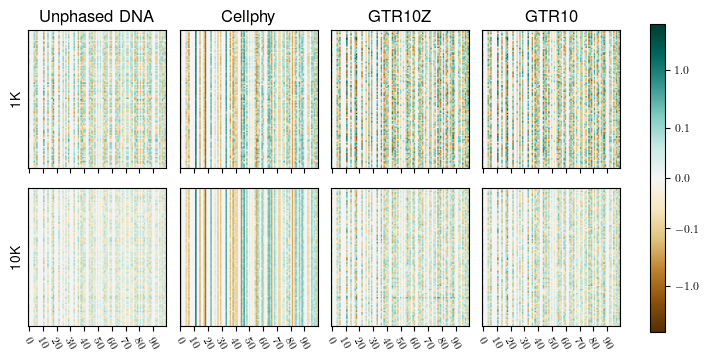

In [43]:
fig, axs = plt.subplots(2, 4, figsize=(7.0, 3.5), layout="constrained", sharex=True)

images = []

for idx in range(4):
    images.append(
        axs[0, idx].imshow((Qs_1K[idx, :, :] - true_Q[0]).reshape(100, -1),
        norm=norm, 
        # norm=fixed_norm, 
        cmap=cmap)
    )
    axs[0, idx].title.set_text(model_text[models[idx]])
    axs[0, idx].set_yticks([])

for idx in range(4):
    images.append(
        axs[1, idx].imshow((Qs_10K[idx, :, :] - true_Q[0]).reshape(100, -1),
        norm=norm,
        # norm=fixed_norm, 
        cmap=cmap)
    )
    axs[1, idx].tick_params(rotation=-60, labelsize=8)
    axs[1, idx].set_xticks(list(range(0, 100, 10)))
    axs[1, idx].set_yticks([])

axs[0, 0].set_ylabel("1K")
axs[1, 0].set_ylabel("10K")

cbar = fig.colorbar(
    images[-1],
    ax=axs,
    ticks=[-3.0, -1.0, -0.1, 0.0, 0.1, 1.0, 3.0],
    shrink=1.0,
    location="right",
)
cbar.ax.tick_params(labelsize=8)

plt.show()

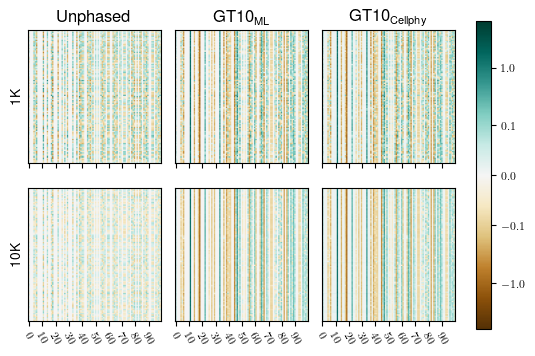

In [47]:
Qs_raxml_1K = get_Qs(get_data("/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/cellphy-model-fit.csv"), "RAXML-NG")
Qs_raxml_10K = get_Qs(get_data("/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/cellphy-model-fit.csv"), "RAXML-NG")

fig, axs = plt.subplots(2, 3, figsize=(5.25, 3.5), layout="constrained", sharex=True)

images = []

for idx in range(2):
    images.append(
        axs[0, idx].imshow((Qs_1K[idx, :, :] - true_Q[0]).reshape(100, -1),
        norm=norm, 
        # norm=fixed_norm, 
        cmap=cmap)
    )
    axs[0, idx].set_yticks([])

images.append(
    axs[0, 2].imshow((Qs_raxml_1K[:, :] - true_Q[0]).reshape(100, -1),
    norm=norm, 
    # norm=fixed_norm, 
    cmap=cmap)
)
axs[0, 2].set_yticks([])

axs[0, 0].title.set_text("Unphased")
axs[0, 1].title.set_text("GT10\\textsubscript{ML}")
axs[0, 2].title.set_text("GT10\\textsubscript{Cellphy}")


for idx in range(2):
    images.append(
        axs[1, idx].imshow((Qs_10K[idx, :, :] - true_Q[0]).reshape(100, -1),
        norm=norm,
        # norm=fixed_norm, 
        cmap=cmap)
    )
    axs[1, idx].tick_params(rotation=-60, labelsize=8)
    axs[1, idx].set_xticks(list(range(0, 100, 10)))
    axs[1, idx].set_yticks([])

images.append(
    axs[1, 2].imshow((Qs_raxml_10K[:, :] - true_Q[0]).reshape(100, -1),
    norm=norm, 
    # norm=fixed_norm, 
    cmap=cmap)
)
axs[1, 2].tick_params(rotation=-60, labelsize=8)
axs[1, 2].set_xticks(list(range(0, 100, 10)))
axs[1, 2].set_yticks([])


axs[0, 0].set_ylabel("1K")
axs[1, 0].set_ylabel("10K")

cbar = fig.colorbar(
    images[-1],
    ax=axs,
    ticks=[-3.0, -1.0, -0.1, 0.0, 0.1, 1.0, 3.0],
    shrink=1.0,
    location="right",
)
cbar.ax.tick_params(labelsize=8)

plt.savefig("model-comparison.pdf", bbox_inches="tight")
plt.savefig("model-comparison.png", dpi=600, bbox_inches="tight")

In [13]:
avg_Q_1K = np.mean(Qs_1K, axis=1)
avg_Q_1K_diag = np.array(
    [avg_Q_1K[idx] - np.diag(np.diag(avg_Q_1K[idx])) for idx in range(avg_Q_1K.shape[0])]
)

avg_Q_10K = np.mean(Qs_10K, axis=1)
avg_Q_10K_diag = np.array(
    [avg_Q_10K[idx] - np.diag(np.diag(avg_Q_10K[idx])) for idx in range(avg_Q_10K.shape[0])]
)

plot_max = max(np.max(np.abs(avg_Q_1K_diag)), np.max(np.abs(avg_Q_10K_diag)))
running_plot_max = max(plot_max, running_plot_max)

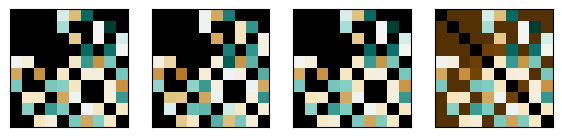

In [14]:
avg_Q_10K_diag[avg_Q_10K_diag == 0.0] = float("nan")

# norm2 = colors.LogNorm(vmin=0.0, vmax=plot_max)
norm2 = make_norm(plot_max, power=1.0 / 3.0, centered=False)

fig, axs = plt.subplots(1, 4, figsize=(7.0, 5.0))

for idx in range(4):
    axs[idx].imshow(avg_Q_10K_diag[idx, :, :], 
                    norm=norm2,
                    # norm = fixed_norm,
                    cmap=cmap)
    axs[idx].set_yticks([])
    axs[idx].set_xticks([])

### differences with the true model

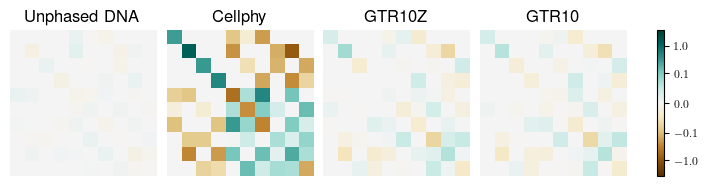

In [15]:
plot_max = np.max(np.abs(avg_Q_10K - true_Q[0]))
running_plot_max = max(plot_max, running_plot_max)

# norm3 = colors.CenteredNorm(vcenter=0.0, halfrange=plot_max)
norm3 = make_norm(plot_max, power=1.0 / 3.0)

fig, axs = plt.subplots(1, 4, figsize=(7.0, 1.75), layout="constrained")

images = []
for idx in range(4):
    images.append(axs[idx].imshow(avg_Q_10K[idx, :, :] - true_Q[0],
                                  #norm=norm3, 
                                  norm=fixed_norm,
                                  cmap=cmap))
    axs[idx].title.set_text(model_text[models[idx]])
    axs[idx].set_axis_off()

cbar = fig.colorbar(
    images[-1],
    ax=axs,
    # ticks=[-1.0, -0.1, -0.01, 0.0, 0.01, 0.1, 1.0],
    ticks=[-1.0, -0.1, 0.0, 0.1, 1.0],
    shrink=1.0,
    location="right",
)
cbar.ax.tick_params(labelsize=8)

plt.savefig("model-error.pdf", bbox_inches="tight")
plt.savefig("model-error.png", dpi=600, bbox_inches="tight")

### distribution of errors

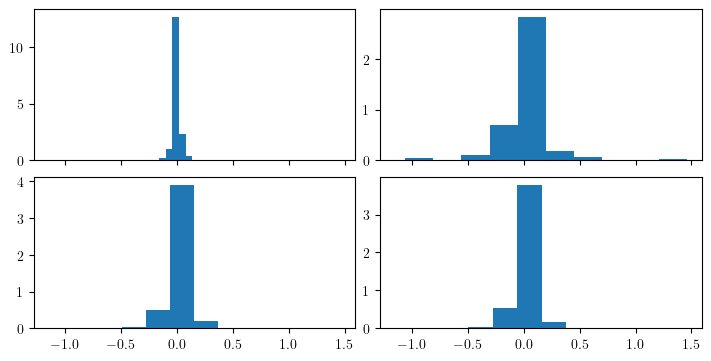

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(7.0, 3.5), layout="constrained", sharex=True)
for idx, ax in zip(range(4), np.array(axs).reshape(-1)):
    ax.hist((Qs_10K[idx] - true_Q[0]).reshape(-1), density=True)

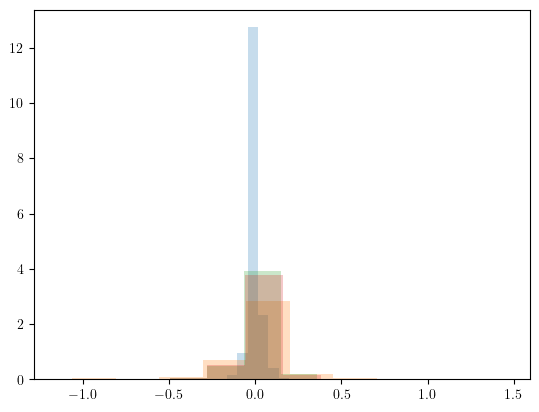

In [17]:
for idx in range(4):
    plt.hist((Qs_10K[idx] - true_Q[0]).reshape(-1), alpha=0.25, density=True)

## comparison of our cellphy fit and raxml-ng's fit

In [18]:
csv_raxml = (
    "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/cellphy-model-fit.csv"
)
csv_cp = "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-cellphy.csv"
csv_unphased = "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-unphased.csv"

In [19]:
Qs_raxml = get_Qs(get_data(csv_raxml), "RAXML-NG")
Qs_cp = get_Qs(get_data(csv_cp), "CELLPHY")
Qs_unphased = get_Qs(get_data(csv_unphased), "UNPHASED_DNA")

<Figure size 640x480 with 0 Axes>

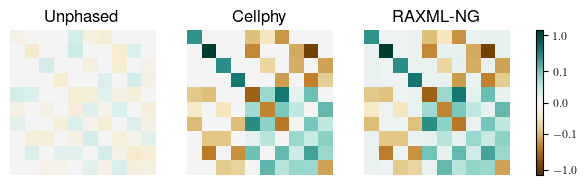

In [20]:
fig = plt.figure()
fig, axs = plt.subplots(1, 3, figsize=(6, 1.75), layout="constrained")

avgdiff_unphased = np.mean(Qs_unphased - true_Q, axis=0)
avgdiff_cp = np.mean(Qs_cp - true_Q, axis=0)
avgdiff_raxml = np.mean(Qs_raxml - true_Q, axis=0)

plot_max = max(
    np.max(np.abs(avgdiff_unphased)), np.max(np.abs(avgdiff_cp)), np.max(np.abs(avgdiff_raxml))
)
running_plot_max = max(plot_max, running_plot_max)
norm = make_norm(plot_max, power=1.0 / 3.0)
# norm = colors.CenteredNorm(vcenter=0.0, halfrange=plot_max)

images = [
    axs[0].imshow(avgdiff_unphased, 
                  cmap=cmap,
                  norm=norm,
                  # norm=fixed_norm,
                 ),
    axs[1].imshow(avgdiff_cp,
                  cmap=cmap,
                  norm=norm,
                  # norm=fixed_norm,
                 ),
    axs[2].imshow(avgdiff_raxml, 
                  cmap=cmap,
                  norm=norm,
                  # norm=fixed_norm,
                 ),
]

axs[0].title.set_text("Unphased")
axs[1].title.set_text("Cellphy")
axs[2].title.set_text("RAXML-NG")

cbar = fig.colorbar(
    images[-1],
    ax=axs,
    # ticks=[-1, -0.1, -0.01, 0.0, 0.01, 0.1, 1],
    ticks=[-1.0, -0.1, 0.0, 0.1, 1.0],
    shrink=1.0,
    location="right",
)
cbar.ax.tick_params(labelsize=8)

axs[0].set_axis_off()
axs[1].set_axis_off()
axs[2].set_axis_off()

# plt.savefig("up-v-cp-v-raxml.pdf", bbox_inches="tight")
# plt.savefig("up-v-cp-v-raxml.png", dpi=600, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

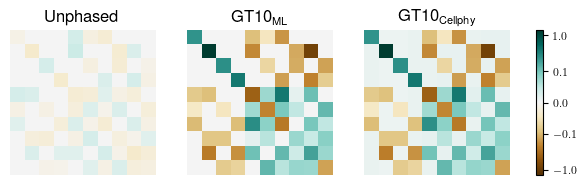

In [21]:
fig = plt.figure()
fig, axs = plt.subplots(1, 3, figsize=(6, 1.75), layout="constrained")

avgdiff_unphased = np.mean(Qs_unphased - true_Q, axis=0)
avgdiff_cp = np.mean(Qs_cp - true_Q, axis=0)
avgdiff_raxml = np.mean(Qs_raxml - true_Q, axis=0)

plot_max = max(
    np.max(np.abs(avgdiff_unphased)), np.max(np.abs(avgdiff_cp)), np.max(np.abs(avgdiff_raxml))
)
running_plot_max = max(plot_max, running_plot_max)
norm = make_norm(plot_max, power=1.0 / 3.0)
# norm = colors.CenteredNorm(vcenter=0.0, halfrange=plot_max)

images = [
    axs[0].imshow(avgdiff_unphased, 
                  cmap=cmap,
                  norm=norm,
                  # norm=fixed_norm,
                 ),
    axs[1].imshow(avgdiff_cp,
                  cmap=cmap,
                  norm=norm,
                  # norm=fixed_norm,
                 ),
    axs[2].imshow(avgdiff_raxml, 
                  cmap=cmap,
                  norm=norm,
                  # norm=fixed_norm,
                 ),
]

axs[0].title.set_text("Unphased")
axs[1].title.set_text("GT10\\textsubscript{ML}")
axs[2].title.set_text("GT10\\textsubscript{Cellphy}")

cbar = fig.colorbar(
    images[-1],
    ax=axs,
    # ticks=[-1, -0.1, -0.01, 0.0, 0.01, 0.1, 1],
    ticks=[-1.0, -0.1, 0.0, 0.1, 1.0],
    shrink=1.0,
    location="right",
)
cbar.ax.tick_params(labelsize=8)

axs[0].set_axis_off()
axs[1].set_axis_off()
axs[2].set_axis_off()

plt.savefig("up-v-cp-v-raxml.pdf", bbox_inches="tight")
plt.savefig("up-v-cp-v-raxml.png", dpi=600, bbox_inches="tight")

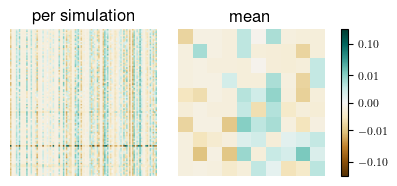

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(4, 1.75), layout="constrained")

ex_dev = Qs_cp - Qs_raxml
avg_dev = np.mean((Qs_cp - Qs_raxml), axis=0)

plot_max = max(np.max(np.abs(ex_dev)), np.max(np.abs(avg_dev)))
running_plot_max = max(plot_max, running_plot_max)
norm = make_norm(plot_max, power=1.0 / 3.0)
# norm = colors.CenteredNorm(vcenter=0.0, halfrange=plot_max)

images = [
    axs[0].imshow((Qs_cp - Qs_raxml).reshape(100, -1),
                  cmap=cmap, 
                  norm=norm,
                  # norm=fixed_norm,
                 ),
    axs[1].imshow(avg_dev, 
                  cmap=cmap,
                  norm=norm,
                  # norm=fixed_norm,
                 ),
]

axs[0].title.set_text("per simulation")
axs[1].title.set_text("mean")

cbar = fig.colorbar(
    images[-1],
    ax=axs,
    ticks=[-0.1, -0.01, 0.0, 0.01, 0.1],
    # ticks=[-3.0, -2.0, -1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0, 2.0, 3.0],
    shrink=1.0,
    location="right",
)
cbar.ax.tick_params(labelsize=8)

axs[0].set_axis_off()
axs[1].set_axis_off()

plt.savefig("cp-v-raxml.pdf", bbox_inches="tight")
plt.savefig("cp-v-raxml.png", dpi=600, bbox_inches="tight")

## 16 state

In [23]:
true_Q16 = get_Qs(np.concatenate(([0], true_pi16s, true_params))[np.newaxis, :], "PHASED_DNA16")

In [24]:
csv_4_1K = "/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-4state.csv"
csv_4_10K = "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-4state.csv"

In [25]:
def four_to_sixteen(data):
    return np.concatenate(
        (
            data[:, 0][:, np.newaxis],
            np.einsum("ni,nj->nij", data[:, 1:5], data[:, 1:5]).reshape(-1, 16),
            data[:, 5:],
        ),
        axis=1,
    )


Qs_4_16_1K = get_Qs(four_to_sixteen(get_data(csv_4_1K)), "PHASED_DNA16")
Qs_4_16_10K = get_Qs(four_to_sixteen(get_data(csv_4_10K)), "PHASED_DNA16")

Text(0.5, 0.98, 'distribution of parameters')

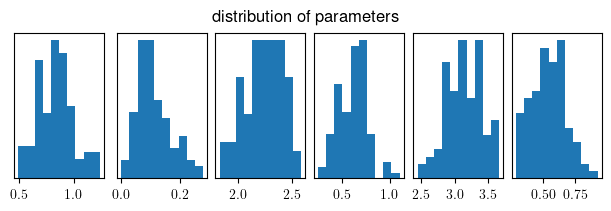

In [26]:
data = get_data(csv_4_10K)

pis = data[:, 1:5]
ss = data[:, 5:]

fig, axs = plt.subplots(1, 6, figsize=(6, 2), layout="constrained")
for idx in range(6):
    axs[idx].hist(ss[:, idx], density=True)
    axs[idx].set_yticks([])

fig.suptitle("distribution of parameters")

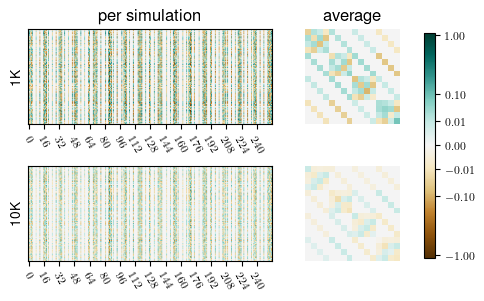

In [27]:
indiv_differences_1K = (Qs_4_16_1K - true_Q16).reshape(-1, 16 * 16)
indiv_differences_10K = (Qs_4_16_10K - true_Q16).reshape(-1, 16 * 16)

differences_1K = np.mean(Qs_4_16_1K, axis=0) - true_Q16[0]
differences_10K = np.mean(Qs_4_16_10K, axis=0) - true_Q16[0]

plot_max = max(
    np.max(np.abs(differences_1K)),
    np.max(np.abs(differences_10K)),
    np.max(np.abs(indiv_differences_1K)),
    np.max(np.abs(indiv_differences_10K)),
)
running_plot_max = max(plot_max, running_plot_max)

norm = make_norm(plot_max, power=1.0 / 3.0)


fig, axs = plt.subplots(2, 2, figsize=(6, 3.25), width_ratios=[2.56, 1], height_ratios=[1, 1])

images = [
    axs[0, 1].imshow(differences_1K,
                     cmap=cmap,
                     norm=norm,
                     # norm=fixed_norm,
                     aspect=1,),
    axs[0, 0].imshow(indiv_differences_1K,
                     cmap=cmap,
                     norm=norm,
                     # norm=fixed_norm,
                     aspect=1,
                    ),
    axs[1, 1].imshow(differences_10K,
                     cmap=cmap,
                     norm=norm,
                     # norm=fixed_norm,
                     aspect=1,
                    ),
    axs[1, 0].imshow(indiv_differences_10K,
                     cmap=cmap,
                     norm=norm,
                     # norm=fixed_norm,
                     aspect=1,
                    ),
]


axs[0, 0].title.set_text("per simulation")
axs[0, 1].title.set_text("average")

axs[0, 0].set_ylabel("1K")
axs[0, 0].set_yticks([])
axs[0, 0].set_xticks(list(range(0, 256, 16)))
axs[0, 0].tick_params(rotation=-60, labelsize=8)

axs[1, 0].set_ylabel("10K")
axs[1, 0].set_yticks([])
axs[1, 0].set_xticks(list(range(0, 256, 16)))
axs[1, 0].tick_params(rotation=-60, labelsize=8)


cbar = fig.colorbar(
    images[-1],
    ax=axs,
    # ticks=[-1.0, -0.25, -0.01, 0.0, 0.01, 0.25, 1.0],
    ticks=[-1.0, -0.1, -0.01, 0.0, 0.01, 0.1, 1.0],
    shrink=0.9,
    location="right",
)
cbar.ax.tick_params(labelsize=8)

axs[0, 1].set_axis_off()
axs[1, 1].set_axis_off()

plt.savefig("16_from_4.pdf", bbox_inches="tight")
plt.savefig("16_from_4.png", dpi=600, bbox_inches="tight")

## 16 state on its own has issues

In [28]:
csv_16_1K = "/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-phased16.csv"
csv_16_10K = "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-phased16.csv"

In [29]:
Qs_16_1K = get_Qs(get_data(csv_16_1K), "PHASED_DNA16")
Qs_16_10K = get_Qs(get_data(csv_16_10K), "PHASED_DNA16")

Text(0, 0.5, '4x4 state')

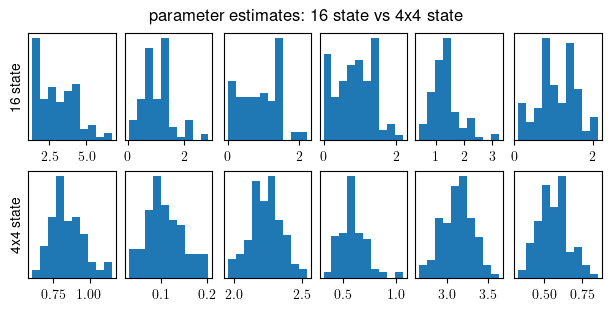

In [30]:
data = get_data(csv_16_10K)

pis = data[:, 1:17]
ss = data[:, 17:]

fig, axs = plt.subplots(2, 6, figsize=(6, 3), layout="constrained")

for idx in range(6):
    axs[0, idx].hist(ss[:, idx], density=True)
    axs[0, idx].set_yticks([])


csv_unphased_10K = "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-unphased.csv"
data = get_data(csv_unphased_10K)

pis = data[:, 1:11]
ss = data[:, 11:]

for idx in range(6):
    axs[1, idx].hist(ss[:, idx], density=True)
    axs[1, idx].set_yticks([])

plt.suptitle("parameter estimates: 16 state vs 4x4 state")
axs[0, 0].set_ylabel("16 state")
axs[1, 0].set_ylabel("4x4 state")

Text(0.5, 0.98, '16 state Q reconstruction error')

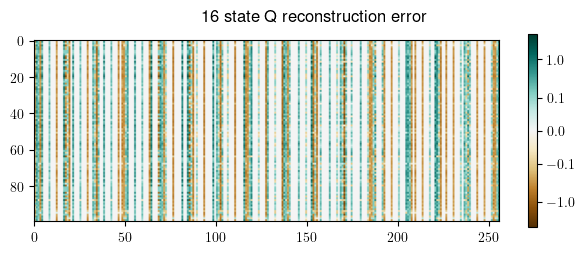

In [31]:
plot_max = np.max(np.abs(Qs_16_10K - true_Q16[0]))
running_plot_max = max(plot_max, running_plot_max)
norm = make_norm(plot_max, power=1.0 / 3.0)

fig = plt.figure(figsize=(7.5, 2.5))
plt.imshow((Qs_16_10K - true_Q16[0]).reshape(100, -1), 
           cmap=cmap,
           norm=norm,
           # norm=fixed_norm,
          )
plt.colorbar(ticks=[-1.0, -0.1, 0.0, 0.1, 1.0],)
plt.suptitle("16 state Q reconstruction error")

Text(0.5, 0.98, '16 state mean est Q vs. true')

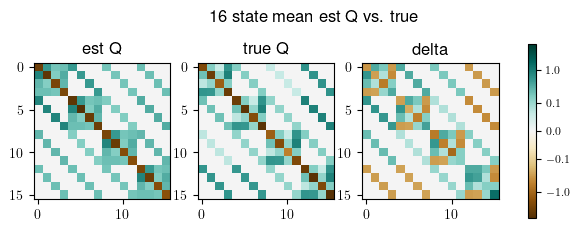

In [32]:
plot_max = max(
    np.max(np.abs(np.mean(Qs_16_10K, axis=0))),
    np.max(np.abs(true_Q16[0])),
    np.max(np.abs(np.mean(Qs_16_10K, axis=0) - true_Q16[0])),
)
running_plot_max = max(plot_max, running_plot_max)
norm = make_norm(plot_max, power=1.0 / 3.0)

fig, axs = plt.subplots(1, 3, figsize=(7.5, 2.5))

images = [
    axs[0].imshow(np.mean(Qs_16_10K, axis=0),
                  cmap=cmap,
                  norm=norm,
                  # norm=fixed_norm,
                 ),
    axs[1].imshow(true_Q16[0],
                  cmap=cmap,
                  norm=norm,
                  # norm=fixed_norm,
                 ),
    axs[2].imshow(np.mean(Qs_16_10K, axis=0) - true_Q16[0],
                  cmap=cmap, 
                  norm=norm,
                  # norm=fixed_norm,
                 ),
]

axs[0].title.set_text("est Q")
axs[1].title.set_text("true Q")
axs[2].title.set_text("delta")

cbar = fig.colorbar(
    images[-1],
    ax=axs,
    # ticks=[-1.0, -0.25, -0.01, 0.0, 0.01, 0.25, 1.0],
    ticks=[-1.0, -0.1, 0.0, 0.1, 1.0],
    shrink=0.9,
    location="right",
)
cbar.ax.tick_params(labelsize=8)

plt.suptitle("16 state mean est Q vs. true")

In [33]:
running_plot_max

np.float64(3.694072035818847)

# Branch lengths

In [48]:
from collections import defaultdict


def get_bl_data(filename):
    per_model_data = defaultdict(list)
    with open(filename, "r") as csv_file:
        csvreader = csv.reader(csv_file)
        # noinspection PyUnusedLocal
        headers = next(csvreader)[1:]
        for line in csvreader:
            model = line[0].split("-")[0]
            per_model_data[model].append(list(map(float, line[1:])))
    for key in per_model_data:
        per_model_data[key] = np.array(per_model_data[key])
    return headers, per_model_data

In [49]:
base_dir = "/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/"

csv_ts_1K = base_dir + "tree-stats-output.csv"
csv_ts_before_1K = base_dir + "tree-stats-before-lklyhd-opt-output.csv"

csv_ts_raxml_1K = base_dir + "tree-stats-raxml-output.csv"

In [50]:
base_dir = "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/"

csv_ts_10K = base_dir + "tree-stats-output.csv"
csv_ts_before_10K = base_dir + "tree-stats-before-lklyhd-opt-output.csv"

csv_ts_raxml_10K = base_dir + "tree-stats-raxml-output.csv"

In [51]:
headers, data_1K_before = get_bl_data(csv_ts_before_1K)
headers, data_1K = get_bl_data(csv_ts_1K)
print(list(enumerate(headers)))
print(data_1K.keys())

[(0, 'SPR'), (1, 'RF'), (2, 'wRF'), (3, 'KF'), (4, 'path'), (5, 'treedist.symmetric'), (6, 'treedist.branch.score'), (7, 'treedist.path'), (8, 'treedist.quadratic.path')]
dict_keys(['4state', 'unphased', 'cellphy', 'gtr10z', 'gtr10', 'phased_dna16', 'phased_dna16_4'])


In [52]:
headers, data_10K_before = get_bl_data(csv_ts_before_10K)
headers, data_10K = get_bl_data(csv_ts_10K)
print(list(enumerate(headers)))
print(data_10K.keys())

[(0, 'SPR'), (1, 'RF'), (2, 'wRF'), (3, 'KF'), (4, 'path'), (5, 'treedist.symmetric'), (6, 'treedist.branch.score'), (7, 'treedist.path'), (8, 'treedist.quadratic.path')]
dict_keys(['4state', 'unphased', 'cellphy', 'gtr10z', 'gtr10', 'phased_dna16', 'phased_dna16_4'])


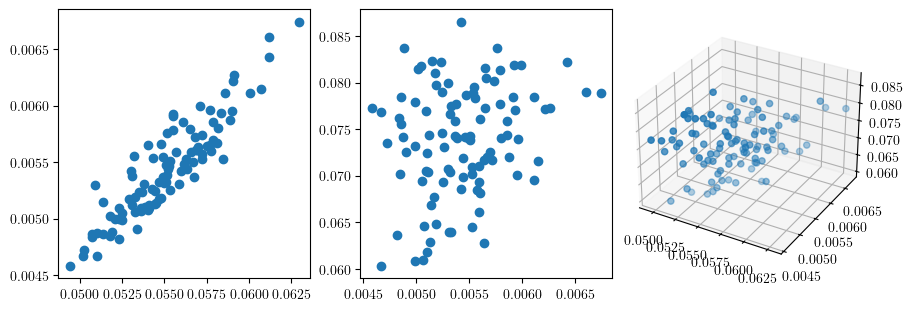

In [53]:
# comparison of distance measures

fig = plt.figure(figsize=(9,3), layout='constrained')

ax = fig.add_subplot(1, 3, 1)
ax.scatter(data_1K['4state'][:,2], data_1K['4state'][:,6])

ax = fig.add_subplot(1, 3, 2)
ax.scatter(data_1K['4state'][:,6], data_1K['4state'][:,8])

ax = fig.add_subplot(1, 3, 3, projection='3d')
ax.scatter(data_1K['4state'][:,2],  data_1K['4state'][:,6], data_1K['4state'][:,8])

In [54]:
headers_raxml, data_raxml_1K = get_bl_data(csv_ts_raxml_1K)
print(data_raxml_1K.keys())

dict_keys(['raxml', 'raxmlscaled'])


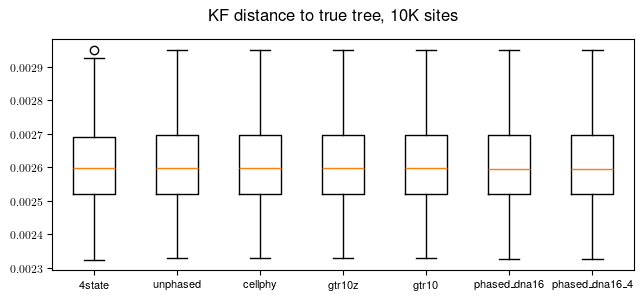

In [55]:
# plot_models = ["4state", "phased16", "phased16mp", "unphased", "cellphy", "gtr10z", "gtr10"]
plot_models = ["4state", "unphased", "cellphy", "gtr10z", "gtr10", "phased_dna16", "phased_dna16_4"]

fig = plt.figure(figsize=(7.5,3))

plt.boxplot(
    [data_10K_before[model][:, 3] for model in plot_models],
    # + [data_raxml_1K["raxml"][:, 3], data_raxml_1K["raxmlscaled"][:, 3]],
    tick_labels=plot_models, # tick_labels=plot_models + ["raxml", "raxmlscaled"],
    bootstrap=100,
)

plt.gca().tick_params(labelsize=8)
plt.suptitle("KF distance to true tree, 10K sites")
plt.show()

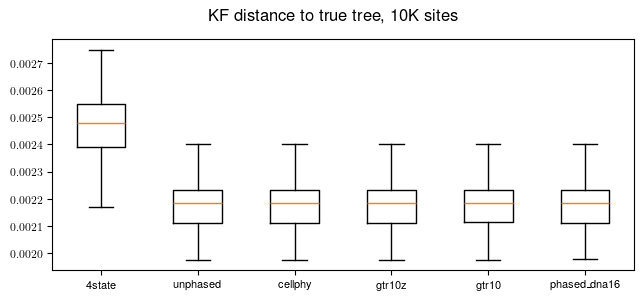

In [56]:
# plot_models = ["4state", "phased16", "phased16mp", "unphased", "cellphy", "gtr10z", "gtr10"]
# plot_models = ["4state", "unphased", "cellphy", "gtr10z", "gtr10", "phased_dna16", "phased_dna16_4"]
plot_models = ["4state", "unphased", "cellphy", "gtr10z", "gtr10", "phased_dna16"]

fig = plt.figure(figsize=(7.5,3))

plt.boxplot(
    [data_10K[model][:, 3] for model in plot_models],
    # + [data_raxml_1K["raxml"][:, 3], data_raxml_1K["raxmlscaled"][:, 3]],
    tick_labels=plot_models, # tick_labels=plot_models + ["raxml", "raxmlscaled"],
    bootstrap=100,
)

plt.gca().tick_params(labelsize=8)
plt.suptitle("KF distance to true tree, 10K sites")
plt.show()

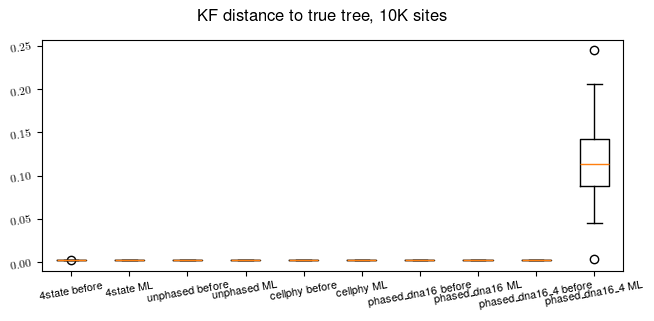

In [57]:
fig = plt.figure(figsize=(7.5,3))

plt.boxplot(
    [
        data_10K_before["4state"][:, 3], data_10K["4state"][:, 3],
        data_10K_before["unphased"][:, 3], data_10K["unphased"][:, 3],
        data_10K_before["cellphy"][:, 3], data_10K["cellphy"][:, 3],
        data_10K_before["phased_dna16"][:, 3], data_10K["phased_dna16"][:, 3],
        data_10K_before["phased_dna16_4"][:, 3], data_10K["phased_dna16_4"][:, 3],
    ],
    # + [data_raxml_1K["raxml"][:, 3], data_raxml_1K["raxmlscaled"][:, 3]],
    tick_labels=[
        "4state before", "4state ML",
        "unphased before", "unphased ML",
        "cellphy before", "cellphy ML",
        "phased_dna16 before", "phased_dna16 ML",
        "phased_dna16_4 before", "phased_dna16_4 ML",
    ],
)

plt.gca().tick_params(labelsize=8, labelrotation=10)
plt.suptitle("KF distance to true tree, 10K sites")
plt.show()

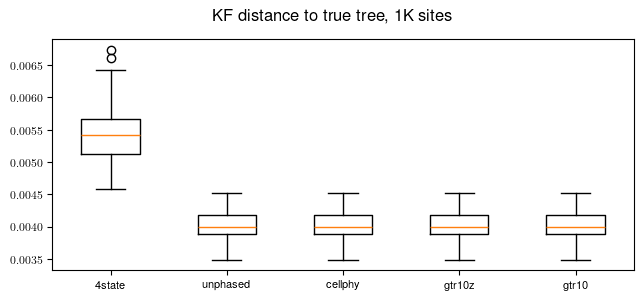

In [58]:
plot_models = ["4state", "unphased", "cellphy", "gtr10z", "gtr10"]

fig = plt.figure(figsize=(7.5,3))

plt.boxplot(
    [data_1K[model][:, 3] for model in plot_models],
    tick_labels=plot_models,
    bootstrap=100,
)

plt.gca().tick_params(labelsize=8)
plt.suptitle("KF distance to true tree, 1K sites")
plt.show()

In [59]:
base_dir = "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/"

csv_ts_10K = (
    base_dir + "tree-stats-output.csv"
)
csv_ts_raxml_10K = base_dir + "tree-stats-raxml-output.csv"


In [60]:
headers, data_10K = get_bl_data(csv_ts_10K)
print(list(enumerate(headers)))
print(data_1K.keys())

[(0, 'SPR'), (1, 'RF'), (2, 'wRF'), (3, 'KF'), (4, 'path'), (5, 'treedist.symmetric'), (6, 'treedist.branch.score'), (7, 'treedist.path'), (8, 'treedist.quadratic.path')]
dict_keys(['4state', 'unphased', 'cellphy', 'gtr10z', 'gtr10', 'phased_dna16', 'phased_dna16_4'])


In [61]:
headers_raxml, data_raxml_1K = get_bl_data(csv_ts_raxml_1K)
headers_raxml, data_raxml_10K = get_bl_data(csv_ts_raxml_10K)
print(data_raxml_1K.keys())

dict_keys(['raxml', 'raxmlscaled'])


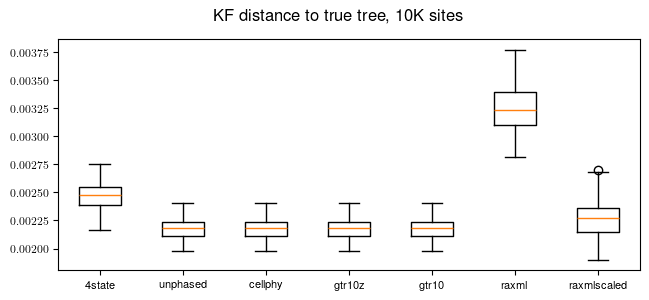

In [62]:
# plot_models = ["4state", "phased16", "phased16mp", "unphased", "cellphy", "gtr10z", "gtr10"]
plot_models = ["4state", "unphased", "cellphy", "gtr10z", "gtr10"]

fig = plt.figure(figsize=(7.5,3))

plt.boxplot(
    [data_10K[model][:, 3] for model in plot_models]
    + [data_raxml_10K["raxml"][:, 3], data_raxml_10K["raxmlscaled"][:, 3]],
    tick_labels=plot_models + ["raxml", "raxmlscaled"],
    bootstrap=100,
)

plt.gca().tick_params(labelsize=8)
plt.suptitle("KF distance to true tree, 10K sites")
plt.show()

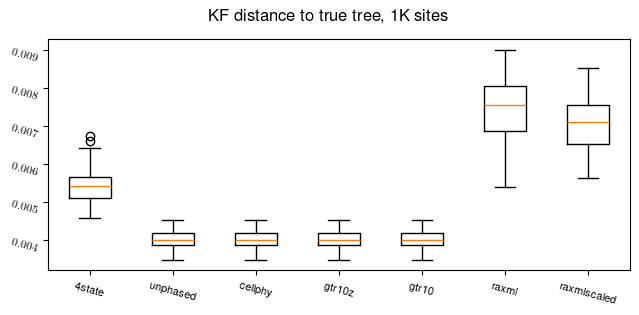

In [63]:
# plot_models = ["4state", "phased16", "phased16mp", "unphased", "cellphy", "gtr10z", "gtr10"]
plot_models = ["4state", "unphased", "cellphy", "gtr10z", "gtr10"]

fig = plt.figure(figsize=(7.5,3))

plt.boxplot(
    [data_1K[model][:, 3] for model in plot_models]
    + [data_raxml_1K["raxml"][:, 3], data_raxml_1K["raxmlscaled"][:, 3]],
    tick_labels=plot_models + ["raxml", "raxmlscaled"],
    bootstrap=100,
)

plt.gca().tick_params(rotation=-15, labelsize=8)
plt.suptitle("KF distance to true tree, 1K sites")
plt.show()

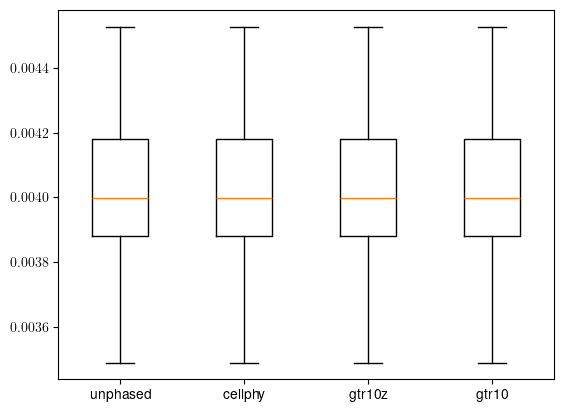

In [64]:
# plot_models = ["phased16", "unphased", "cellphy", "gtr10z", "gtr10"]
plot_models = ["unphased", "cellphy", "gtr10z", "gtr10"]

plt.boxplot([data_1K[model][:, 3] for model in plot_models], tick_labels=plot_models, bootstrap=100)

plt.show()

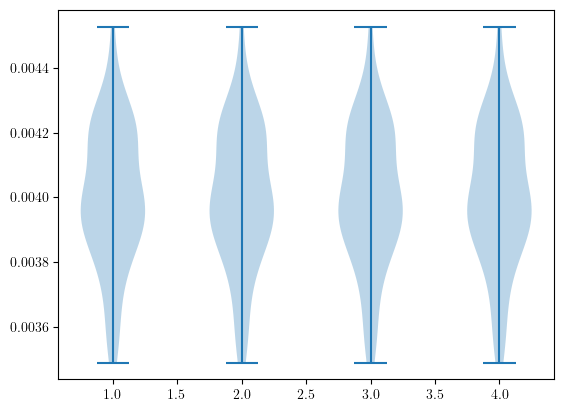

In [65]:
plot_models = ["unphased", "cellphy", "gtr10z", "gtr10"]

plt.violinplot(
    [data_1K[model][:, 3] for model in plot_models],
    # tick_labels= plot_models,
    # bootstrap=100
)

plt.show()

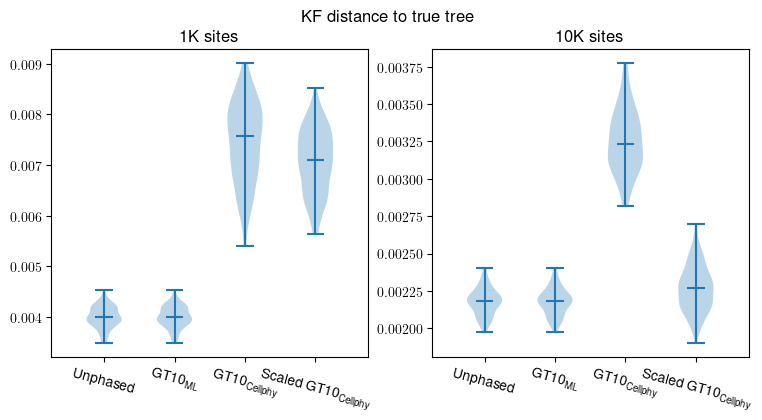

In [119]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

ax1.violinplot(
    [
        data_1K["unphased"][:,3],
        data_1K["cellphy"][:,3],
        data_raxml_1K["raxml"][:, 3],
        data_raxml_1K["raxmlscaled"][:, 3]
    ],
    # showmeans=True,
    showmedians=True,
    showextrema=True,
)

ax1.set_xticks(
    np.arange(1, 4 + 1), 
    labels=[
        "Unphased",
        "GT10\\textsubscript{ML}",
        "GT10\\textsubscript{Cellphy}",
        "Scaled GT10\\textsubscript{Cellphy}",
    ],
    rotation=-15,
)
ax1.set_xlim(0.25, 4 + 0.75)
ax1.set_title("1K sites")


ax2.violinplot(
    [
        data_10K["unphased"][:,3],
        data_10K["cellphy"][:,3],
        data_raxml_10K["raxml"][:, 3],
        data_raxml_10K["raxmlscaled"][:, 3]
    ],
    # showmeans=True,
    showmedians=True,
    showextrema=True,
)

ax2.set_xticks(
    np.arange(1, 4 + 1), 
    labels=[
        "Unphased",
        "GT10\\textsubscript{ML}",
        "GT10\\textsubscript{Cellphy}",
        "Scaled GT10\\textsubscript{Cellphy}",
    ],
    rotation=-15,
)
ax2.set_xlim(0.25, 4 + 0.75)
ax2.set_title("10K sites")



fig.suptitle("KF distance to true tree")

plt.show()
# plt.savefig("branch_lens.pdf", bbox_inches="tight")
# plt.savefig("branch_lens.png", dpi=600, bbox_inches="tight")

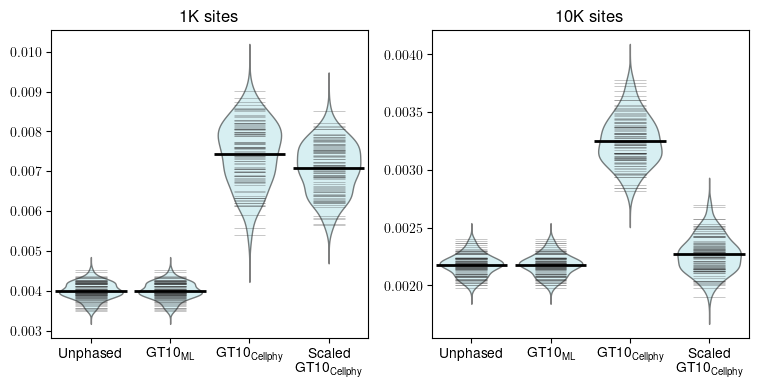

In [134]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

bean_opts = {
    'violin_width': 0.8,
    'violin_fc': 'powderblue',
    'bean_color': '#30303060',
    'bean_size': 0.4,
    # 'bean_lw': 0.125,
    'bean_mean_size': 1.5,
    'bean_mean_color': 'k',
    'bean_mean_lw': 2,
    'jitter_marker': '+',
    'jitter_marker_size': 2,
    'bean_show_median': False,
}

beanplot(
    [
        data_1K["unphased"][:,3],
        data_1K["cellphy"][:,3],
        data_raxml_1K["raxml"][:, 3],
        data_raxml_1K["raxmlscaled"][:, 3]
    ],
    ax=ax1,
    # jitter=True,
    plot_opts=bean_opts,
)

ax1.set_xticks(
    np.arange(1, 4 + 1), 
    labels=[
        "Unphased",
        "GT10\\textsubscript{ML}",
        "GT10\\textsubscript{Cellphy}",
        "Scaled\nGT10\\textsubscript{Cellphy}",
    ],
    # rotation=-15,
)
ax1.set_title("1K sites")

beanplot(
    [
        data_10K["unphased"][:,3],
        data_10K["cellphy"][:,3],
        data_raxml_10K["raxml"][:, 3],
        data_raxml_10K["raxmlscaled"][:, 3]
    ],
    ax=ax2,
    plot_opts=bean_opts,
)

ax2.set_xticks(
    np.arange(1, 4 + 1), 
    labels=[
        "Unphased",
        "GT10\\textsubscript{ML}",
        "GT10\\textsubscript{Cellphy}",
        "Scaled\nGT10\\textsubscript{Cellphy}",
    ],
    # rotation=-15,
)
ax2.set_title("10K sites")

# 
plt.savefig("branch_lens.pdf", bbox_inches="tight")
plt.savefig("branch_lens.png", dpi=600, bbox_inches="tight")